In [1]:
from chipanalysis.utils.file_reader import *
from chipanalysis.utils.maye_video_axio  import *

from pathlib import Path
from aicspylibczi import CziFile
import matplotlib.pyplot as plt
import numpy as np
from chipanalysis.utils.ROI_selector import ROI_selector, ROI_selector_down
from PIL import Image
import pandas as pd
import numpy as np

%matplotlib widget

In [2]:
root_path = "/Users/bisot/Documents/PostDoc2/test_data"
# root_path = "/Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac"

fig_path = "/Users/bisot/Documents/PostDoc2/test_data"

czi_name = "CB27-01.czi"
# czi_name = "CB1-04_S1.czi"

czi_path = Path(root_path,czi_name)
czi = CziFile(czi_path)

dims = czi.dims
sizes = czi.size

dim_sizes = dict(zip(dims, sizes))
dim_sizes["T"]
pixel_size = get_pixel_sizes_um(czi)
times = get_timestamps_by_T(czi, C=0, Z=0)


.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value


In [3]:
channel = 2
time = 0
img, img_disp = get_frame(czi,time,channel)

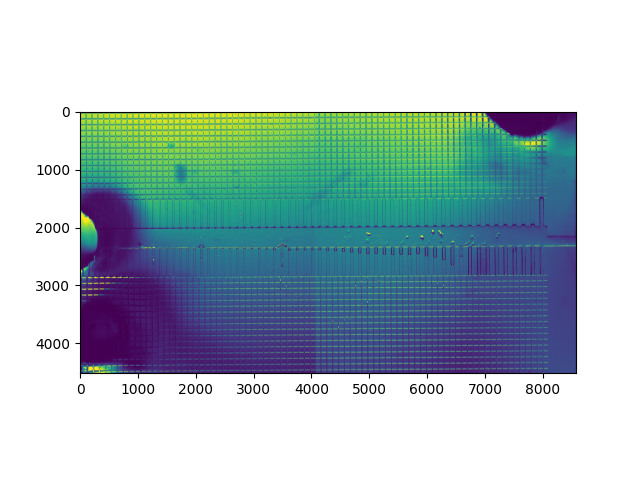

In [4]:
fig,ax = plt.subplots()
ax.imshow(img_disp)

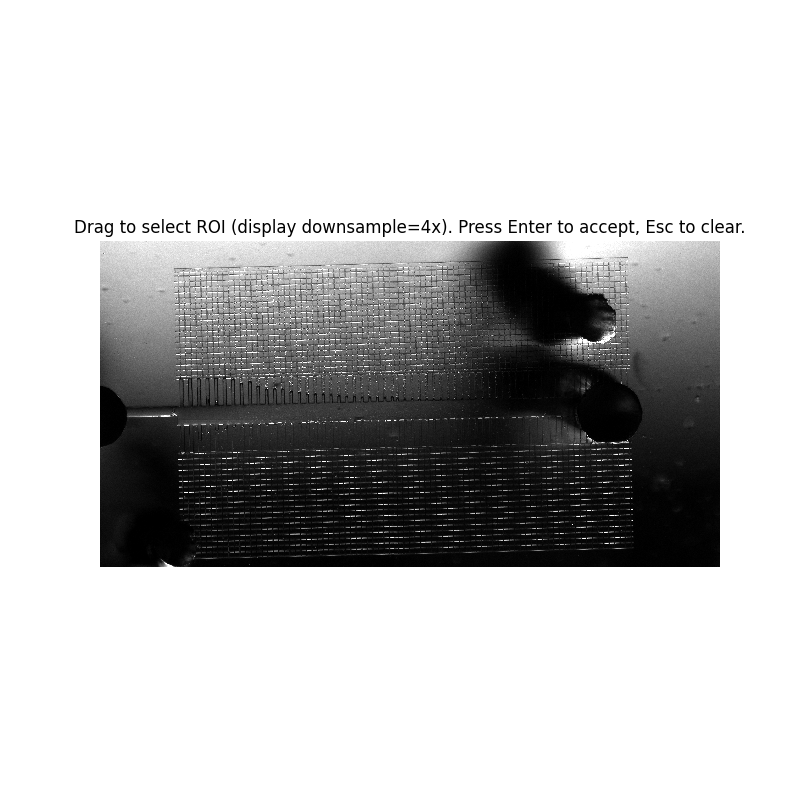

In [50]:
roi_bac = ROI_selector_down(img,4)

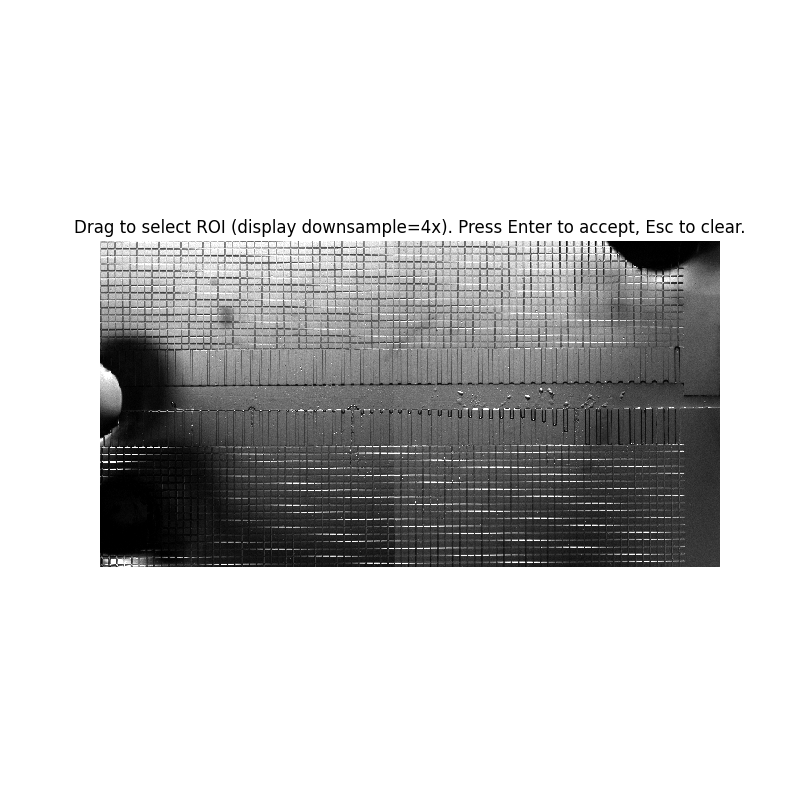

In [ ]:
roi_dic = ROI_selector_down(img,4)


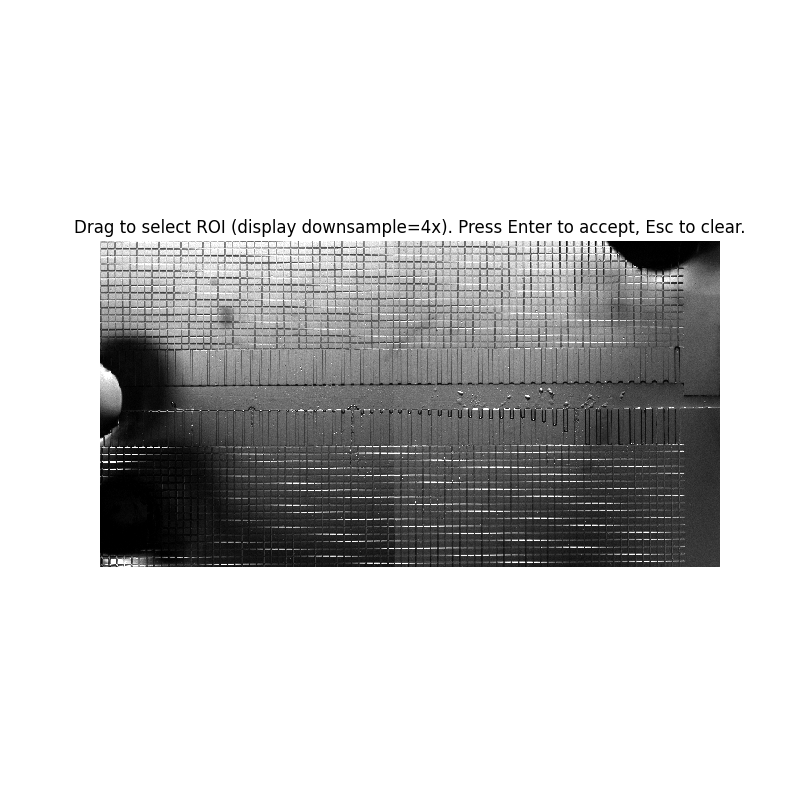

In [ ]:
roi_air = ROI_selector_down(img,4)


In [ ]:

rois = [roi_bac,roi_dic,roi_air]
rois_names = ["roi_bac","roi_dic","roi_air"]




def compute_profiles_over_time_roi(
    czi,
    times,
    channels,
    rois,
    metrics=None
):
    """
    Returns DataFrame with columns:
      t, x, <metric1>, <metric2>, ...
    """
    if metrics is None:
        metrics = {"mean": profile_mean}

    frames = []

    for t in times:
        for channel in channels:
            for roi,roi_name in zip(rois,rois_names):
                img, _ = get_frame(czi, t, channel, roi=roi, gamma=1)
                row = {"t": t,"channel": channel,"roi_name":roi_name}

                for name, fn in metrics.items():
                    y = fn(img)
                    row[name] = y

                frames.append(row)

    return pd.DataFrame(frames)

In [36]:
from skimage import exposure
from skimage.feature import blob_dog, blob_log, blob_doh

def profile_mean(img):      return np.mean(img)
def count_cells(img):
    print(img.shape)
    img = img.astype(float)
    img = exposure.rescale_intensity(img, in_range='image', out_range=(0,1))
    img = (img - img.mean()) / img.std()

    image_gray = img

    blobs_doh = blob_doh(image_gray, min_sigma=5, max_sigma=20, num_sigma=10, threshold=0.2)
    return(len(blobs_doh))



times = list(range(0, dim_sizes["T"], 1))


metrics = {
    "mean": profile_mean,
    "cell_count": count_cells
}
channels = [0,1]

datatable = compute_profiles_over_time_roi(czi, times, channels, rois=rois, metrics=metrics)

(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)
(2118, 6751)
(333, 6654)
(1924, 6240)

In [11]:
datatable = pd.read_csv("/Users/bisot/Documents/PostDoc2/chipanalysis/time_dynamic2.csv")
datatable = datatable[datatable["t"]!=250]

In [12]:
df = datatable.copy()
# times_tab = get_timestamps_by_T(czi, C=0, Z=0)
# times_df = pd.DataFrame(times_tab, columns=["t", "timestr"])
# df = df.merge(times_df, on="t", how="left")

# df["datetime"] = pd.to_datetime(df["timestr"], utc=True)
# t0 = df.loc[df["t"] == 0, "datetime"].iloc[0]

# df["timedelta_from_0"] = df["datetime"] - t0
# df["timedelta_hours"] = df["timedelta_from_0"].dt.total_seconds()/3600
df["timedelta_hours"] = df["t"]*10/60


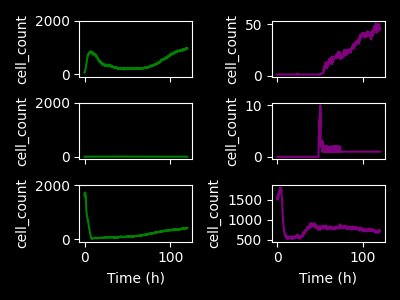

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('dark_background')

channels = [0, 1]
rois = ["roi_bac", "roi_air", "roi_dic"]

colors = {0: "green", 1: "purple"}
names = {0: "B. subtilis", 1: "D. discoideum"}

fig, axes = plt.subplots(len(rois), len(channels), figsize=(4, 3), sharex=True, sharey=False)

for j, channel in enumerate(channels):
    for i, roi in enumerate(rois):
        
        ax = axes[i, j]
        sub = df[(df["channel"] == channel) & (df["roi_name"] == roi)]

        sns.lineplot(
            data=sub,
            x="timedelta_hours",
            y="cell_count",
            color=colors[channel],
            ax=ax,
            
        )
        if channel == 0:
            ax.set_ylim(-100,2000)
        # ax.set_title(f"{names[channel]} — {roi}")
        ax.set_xlabel("Time (h)")
        # ax.set_ylabel("Number of cells")

plt.tight_layout()
plt.show()

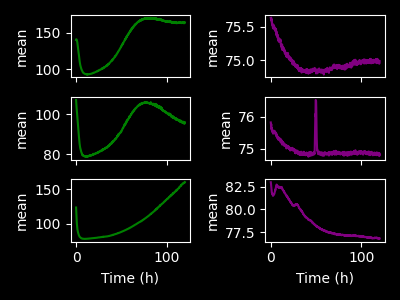

In [15]:

import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use('dark_background')

channels = [0, 1]
rois = ["roi_bac", "roi_air", "roi_dic"]

colors = {0: "green", 1: "purple"}
names = {0: "B. subtilis", 1: "D. discoideum"}

fig, axes = plt.subplots(len(rois), len(channels), figsize=(4, 3), sharex=True, sharey=False)

for j, channel in enumerate(channels):
    for i, roi in enumerate(rois):
        
        ax = axes[i, j]
        sub = df[(df["channel"] == channel) & (df["roi_name"] == roi)]

        sns.lineplot(
            data=sub,
            x="timedelta_hours",
            y="mean",
            color=colors[channel],
            ax=ax,
            
        )
        # if channel == 0:
        #     ax.set_ylim(-100,8000)
        # ax.set_title(f"{names[channel]} — {roi}")
        ax.set_xlabel("Time (h)")
        # ax.set_ylabel("Number of cells")

plt.tight_layout()
plt.show()

In [7]:
df[df["timedelta_hours"].between(41.6,41.7)]

,Unnamed: 0,t,channel,roi_name,mean,cell_count,timedelta_hours
1500,1500,250,0,roi_bac,95.94163,2048,41.666667
1501,1501,250,0,roi_dic,94.59102,1010,41.666667
1502,1502,250,0,roi_air,94.02320,44,41.666667
1503,1503,250,1,roi_bac,93.32210,1166,41.666667
1504,1504,250,1,roi_dic,89.30323,967,41.666667
1505,1505,250,1,roi_air,89.67499,44,41.666667
